Link to Temperature.grib file: https://drive.google.com/file/d/1adOKVyI4geheKsZjLjiD60O68WHkAQCe/view?usp=drive_link

Link to merged dataset (csv): https://drive.google.com/file/d/1Z2wiCBoWl1O1AyqUv4qru96grVwT3ZrI/view?usp=drive_link

In [ ]:
%pip install xarray cfgrib matplotlib pandas seaborn cartopy


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# EDA STAGE - TEMPERATURE DATASET

In [94]:
import xarray as xr

# Load the dataset
ds = xr.open_dataset("temperature.grib", engine="cfgrib")
print(ds)
ds.head()

skipping variable: paramId==235 shortName='skt'
Traceback (most recent call last):
  File "C:\Users\Taimur Ahmad\AppData\Roaming\Python\Python312\site-packages\cfgrib\dataset.py", line 725, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "C:\Users\Taimur Ahmad\AppData\Roaming\Python\Python312\site-packages\cfgrib\dataset.py", line 641, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='step' value=Variable(dimensions=(), data=24.0) new_value=Variable(dimensions=(), data=0.0)


<xarray.Dataset>
Dimensions:     (time: 84, latitude: 1801, longitude: 3600)
Coordinates:
    number      int32 ...
  * time        (time) datetime64[ns] 2017-01-01 2017-02-01 ... 2023-12-01
    step        timedelta64[ns] ...
    surface     float64 ...
  * latitude    (latitude) float64 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * longitude   (longitude) float64 0.0 0.1 0.2 0.3 ... 359.6 359.7 359.8 359.9
    valid_time  (time) datetime64[ns] ...
Data variables:
    d2m         (time, latitude, longitude) float32 ...
    t2m         (time, latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-04-22T01:14 GRIB to CDM+CF via cfgrib-0.9.1...


<xarray.Dataset>
Dimensions:     (time: 5, latitude: 5, longitude: 5)
Coordinates:
    number      int32 ...
  * time        (time) datetime64[ns] 2017-01-01 2017-02-01 ... 2017-05-01
    step        timedelta64[ns] ...
    surface     float64 ...
  * latitude    (latitude) float64 90.0 89.9 89.8 89.7 89.6
  * longitude   (longitude) float64 0.0 0.1 0.2 0.3 0.4
    valid_time  (time) datetime64[ns] ...
Data variables:
    d2m         (time, latitude, longitude) float32 ...
    t2m         (time, latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-04-22T01:14 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
import xarray as xr

ds = xr.open_dataset("temperature.grib", engine="cfgrib")

print(ds)

df = ds[['t2m']].to_dataframe().reset_index()

print(df.head())


In [8]:
t2m = xr.open_dataset("temperature.grib", engine="cfgrib", filter_by_keys={'shortName': 't2m'})
d2m = xr.open_dataset("temperature.grib", engine="cfgrib", filter_by_keys={'shortName': 'd2m'})
skt = xr.open_dataset("temperature.grib", engine="cfgrib", filter_by_keys={'shortName': 'skt'})


In [9]:
for name, ds_part in zip(['t2m', 'd2m', 'skt'], [t2m, d2m, skt]):
    print(f"{name.upper()} variables:\n", ds_part)


T2M variables:
 <xarray.Dataset>
Dimensions:  ()
Data variables:
    *empty*
Attributes:
    Conventions:  CF-1.7
    history:      2025-04-21T21:42 GRIB to CDM+CF via cfgrib-0.9.15.0/ecCodes...
D2M variables:
 <xarray.Dataset>
Dimensions:  ()
Data variables:
    *empty*
Attributes:
    Conventions:  CF-1.7
    history:      2025-04-21T21:42 GRIB to CDM+CF via cfgrib-0.9.15.0/ecCodes...
SKT variables:
 <xarray.Dataset>
Dimensions:     (time: 84, latitude: 1801, longitude: 3600)
Coordinates:
    number      int32 ...
  * time        (time) datetime64[ns] 2017-01-01 2017-02-01 ... 2023-12-01
    step        timedelta64[ns] ...
    surface     float64 ...
  * latitude    (latitude) float64 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * longitude   (longitude) float64 0.0 0.1 0.2 0.3 ... 359.6 359.7 359.8 359.9
    valid_time  (time) datetime64[ns] ...
Data variables:
    skt         (time, latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:         

In [6]:
import cfgrib

datasets = cfgrib.open_datasets("temperature.grib")

# Print some info about each dataset to find the one with 't2m' or 'd2m'
for i, ds in enumerate(datasets):
    print(f"Dataset {i}:")
    print(ds)
    print("-" * 50)



Dataset 0:
<xarray.Dataset>
Dimensions:     (time: 84, latitude: 1801, longitude: 3600)
Coordinates:
    number      int32 0
  * time        (time) datetime64[ns] 2017-01-01 2017-02-01 ... 2023-12-01
    step        timedelta64[ns] 1 days
    surface     float64 0.0
  * latitude    (latitude) float64 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * longitude   (longitude) float64 0.0 0.1 0.2 0.3 ... 359.6 359.7 359.8 359.9
    valid_time  (time) datetime64[ns] 2017-01-02 2017-02-02 ... 2023-12-02
Data variables:
    t2m         (time, latitude, longitude) float32 ...
    d2m         (time, latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
--------------------------------------------------
Dataset 1:
<xarray

In [7]:
datasets = cfgrib.open_datasets("temperature.grib")
t2m_d2m = datasets[0]
skt = datasets[1]
t2m = t2m_d2m['t2m']
d2m = t2m_d2m['d2m']



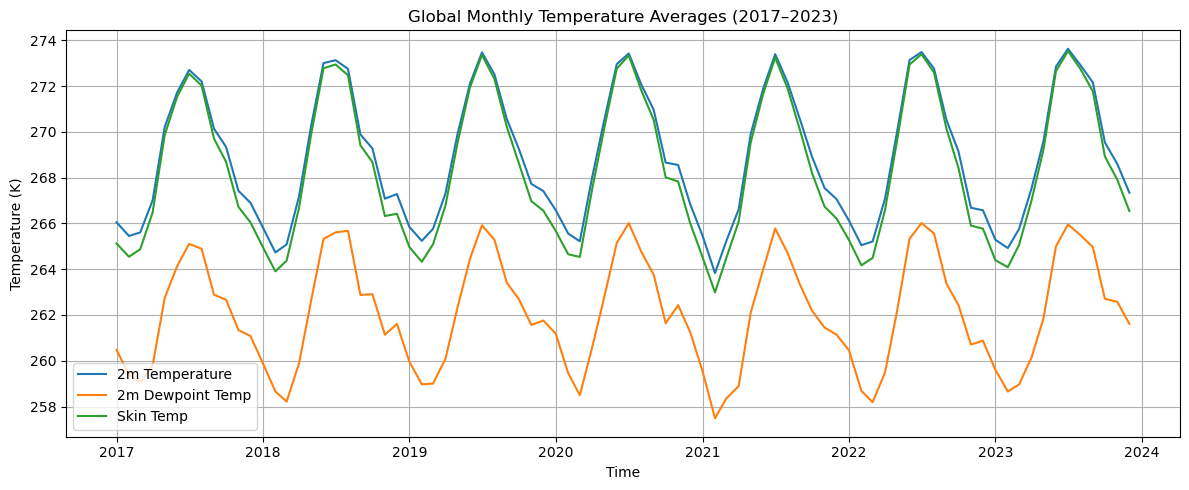

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_avg_temp_over_time(da, label):
    series = da.mean(dim=["latitude", "longitude"])
    series['time'] = pd.to_datetime(series.time.values)
    plt.plot(series.time, series.values, label=label)

plt.figure(figsize=(12, 5))
plot_avg_temp_over_time(t2m, "2m Temperature")
plot_avg_temp_over_time(d2m, "2m Dewpoint Temp")
plot_avg_temp_over_time(skt['skt'], "Skin Temp")
plt.title("Global Monthly Temperature Averages (2017–2023)")
plt.xlabel("Time")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


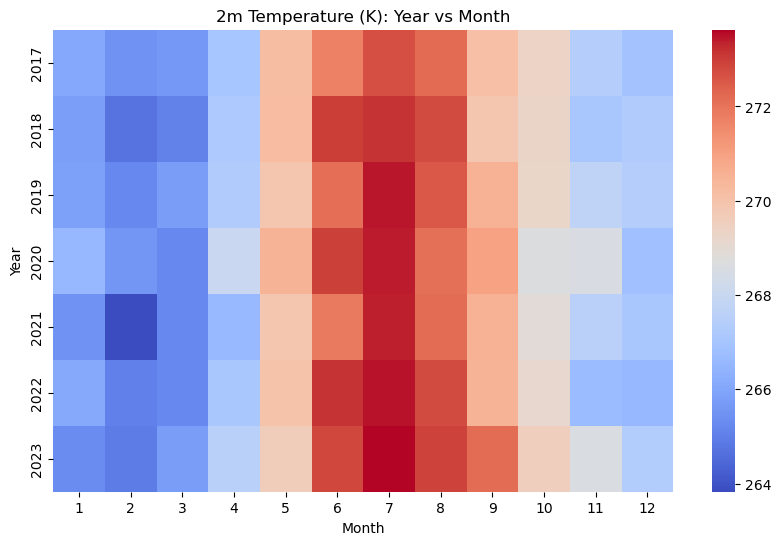

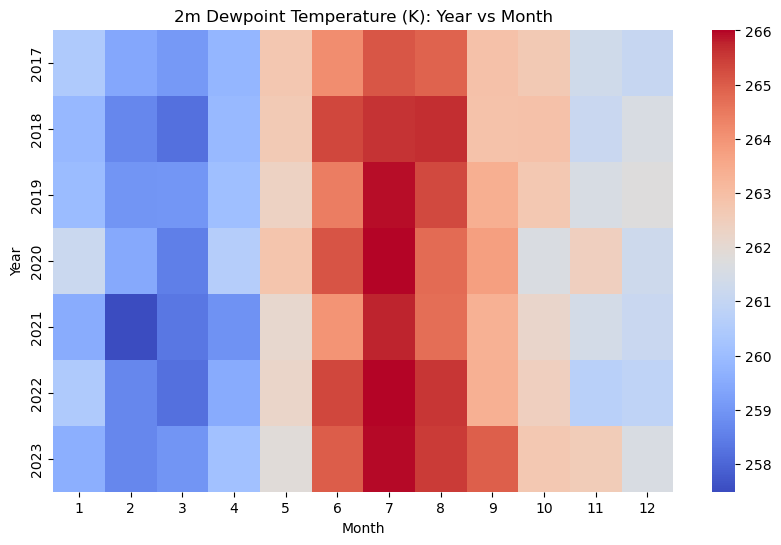

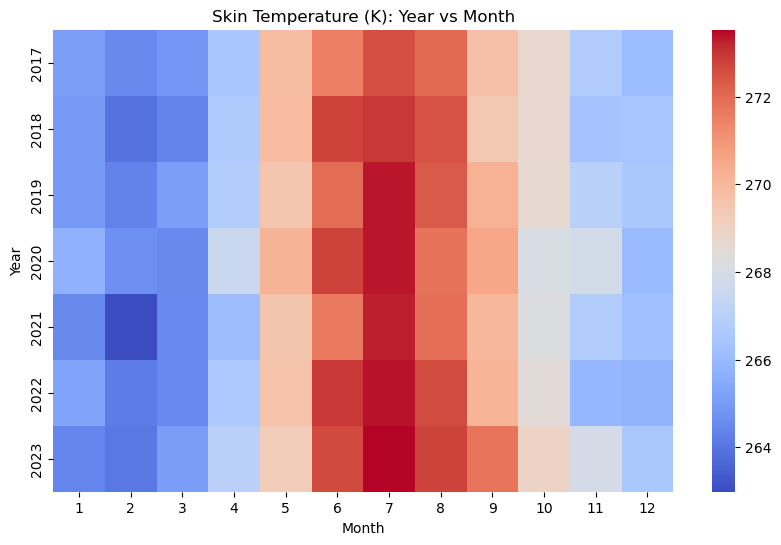

In [ ]:
import seaborn as sns
def plot_heatmap_all(da, label):
    da_avg = da.mean(dim=["latitude", "longitude"])
    
    months = da_avg.time.dt.month.values
    years = da_avg.time.dt.year.values
    temp_vals = da_avg.values  

    df = pd.DataFrame({
        "month": months,
        "year": years,
        "value": temp_vals
    })

    heatmap_data = df.pivot(index="year", columns="month", values="value")

    #Plot
    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, cmap="coolwarm", annot=False)
    plt.title(f"{label} (K): Year vs Month")
    plt.xlabel("Month")
    plt.ylabel("Year")
    plt.show()



plot_heatmap_all(t2m, "2m Temperature")
plot_heatmap_all(d2m, "2m Dewpoint Temperature")
plot_heatmap_all(skt["skt"], "Skin Temperature") 



2m Temperature & Skin Temperature
- Strong seasonal peak around June–August (Northern Hemisphere summer).
- Coldest months are January–March and November–December.
- Skin temperature tracks 2m temperature closely, with very subtle differences — likely higher on average due to surface heating.

2m Dewpoint Temperature
- Also follows a seasonal pattern but is consistently lower than 2m temperature.
- Reflects atmospheric moisture content — more variability year-to-year.
- Slightly less sharp contrast between months compared to T2M.

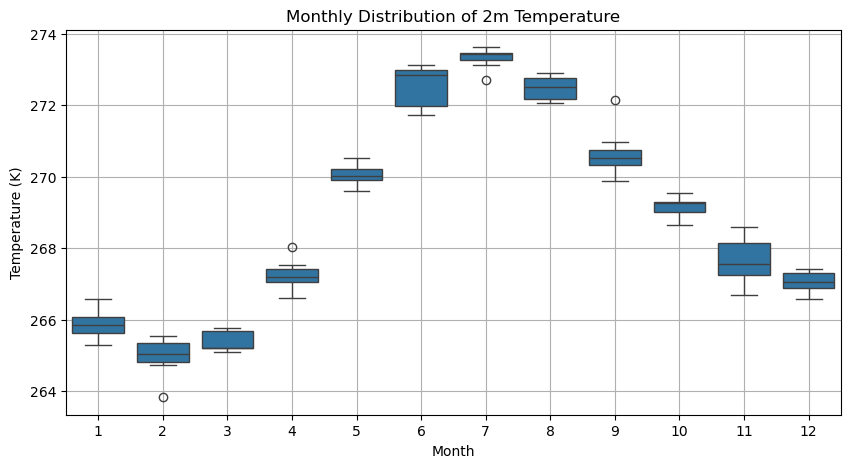

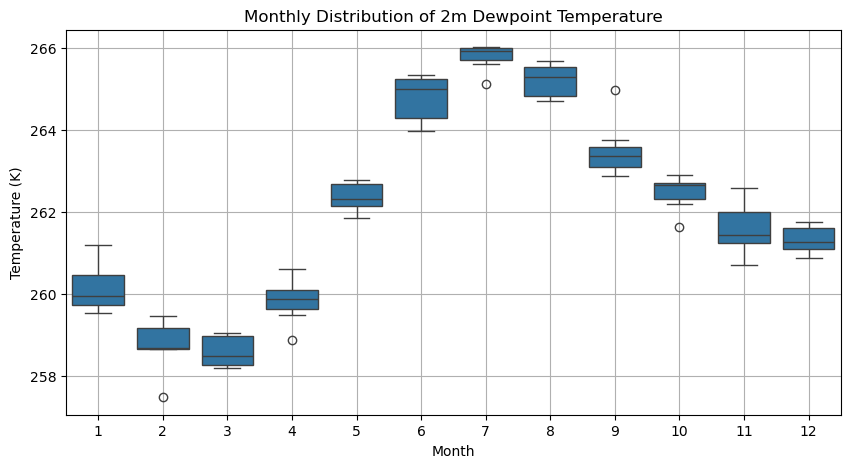

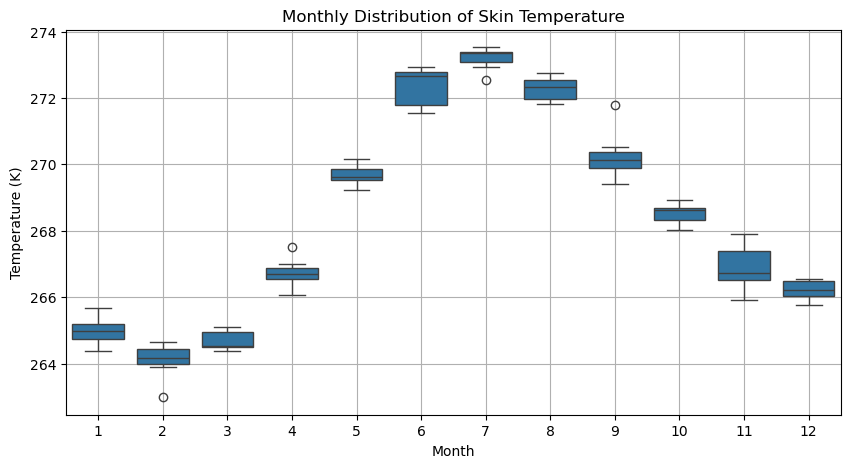

In [29]:
def plot_monthly_boxplot_all(da, label):
    da_avg = da.mean(dim=["latitude", "longitude"])
    df = pd.DataFrame({
        "month": da_avg.time.dt.month,
        "value": da_avg.values
    })
    plt.figure(figsize=(10, 5))
    sns.boxplot(x="month", y="value", data=df)
    plt.title(f"Monthly Distribution of {label}")
    plt.xlabel("Month")
    plt.ylabel("Temperature (K)")
    plt.grid(True)
    plt.show()

plot_monthly_boxplot_all(t2m, "2m Temperature")
plot_monthly_boxplot_all(d2m, "2m Dewpoint Temperature")
plot_monthly_boxplot_all(skt["skt"], "Skin Temperature")


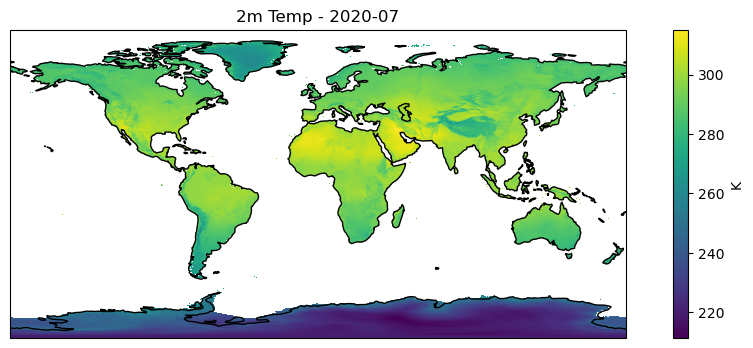

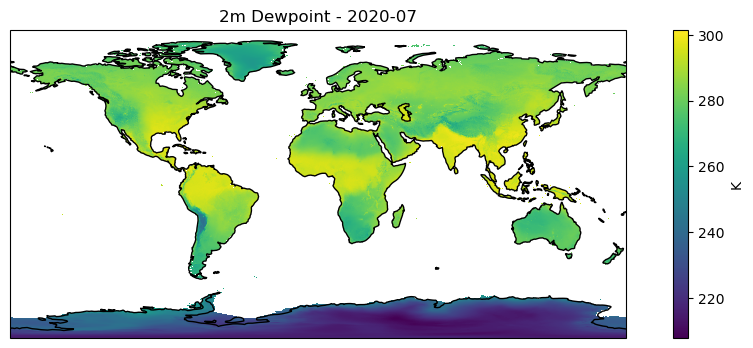

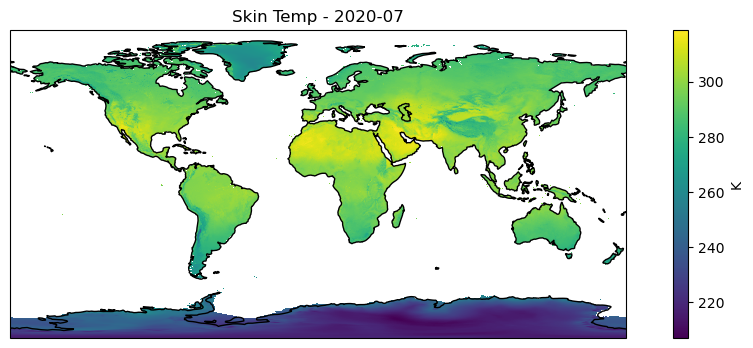

In [33]:
import cartopy.crs as ccrs

def plot_map_month_all(t2m, d2m, skt, year, month):
    idx = ((t2m.time.dt.year == year) & (t2m.time.dt.month == month)).argmax().item()
    data_list = [t2m.isel(time=idx), d2m.isel(time=idx), skt.isel(time=idx)]
    labels = ["2m Temp", "2m Dewpoint", "Skin Temp"]

    for da, label in zip(data_list, labels):
        plt.figure(figsize=(12, 4))
        ax = plt.axes(projection=ccrs.PlateCarree())
        mesh = ax.pcolormesh(da.longitude, da.latitude, da, transform=ccrs.PlateCarree())
        ax.coastlines()
        plt.title(f"{label} - {year}-{month:02}")
        plt.colorbar(mesh, label="K")
        plt.show()

plot_map_month_all(t2m, d2m, skt["skt"], 2020, 7)



# MERGING WITH TEMPERATURE DATASET WITH CLEANED TREE PHENOLOGY DATASET

In [ ]:
import pandas as pd

# Load your phenology CSV
df = pd.read_csv("../../../data/Fall 2024 data/cleaned_alldata_version2.csv")
print(df.columns)
print(df.head())


Index(['Unnamed: 0', 'Date_of_observation', 'Species_name', 'Lat', 'Long',
       'State_name', 'Leaves_fresh', 'Leaves_mature', 'Leaves_old',
       'Flowers_bud', 'Flowers_open', 'Flowers_male', 'Flowers_Female',
       'Fruits_unripe', 'Fruits_ripe', 'Fruits_open', 'Year', 'Week',
       'Species_id'],
      dtype='object')
   Unnamed: 0 Date_of_observation                      Species_name       Lat  \
0           1          2020-01-01  Indian Almond-Terminalia catappa  12.15386   
1           2          2020-01-01  Indian Almond-Terminalia catappa  12.15386   
2           3          2020-01-01      Fish-tail Palm-Caryota urens  12.14060   
3           4          2020-01-01      Mast Tree-Monoon longifolium  12.14060   
4           5          2020-01-01  Indian Almond-Terminalia catappa  12.14060   

       Long State_name  Leaves_fresh  Leaves_mature  Leaves_old  Flowers_bud  \
0  75.22397     Kerala           2.0            0.0         0.0         -2.0   
1  75.22397     Kerala  

In [ ]:
import pandas as pd
import xarray as xr
import numpy as np
from tqdm import tqdm

# Load phenology CSV
df = pd.read_csv("../../../data/Fall 2024 data/cleaned_alldata_version2.csv")
df['Date_of_observation'] = pd.to_datetime(df['Date_of_observation'])

# Function to extract value from xarray DataArray at lat/lon/date
def extract_variable(da, df, time_col, lat_col, lon_col):
    values = []
    for i, row in tqdm(df.iterrows(), total=len(df)):
        try:
            val = da.sel(
                time=row[time_col],
                latitude=row[lat_col],
                longitude=row[lon_col],
                method='nearest'
            ).values.item()
        except:
            val = np.nan
        values.append(val)
    return values

# Attach temperature values
df['t2m_K'] = extract_variable(t2m, df, 'Date_of_observation', 'Lat', 'Long')
df['d2m_K'] = extract_variable(d2m, df, 'Date_of_observation', 'Lat', 'Long')
df['skt_K'] = extract_variable(skt['skt'], df, 'Date_of_observation', 'Lat', 'Long')

# Optional: Convert to Celsius
df['t2m_C'] = df['t2m_K'] - 273.15
df['d2m_C'] = df['d2m_K'] - 273.15
df['skt_C'] = df['skt_K'] - 273.15

# Save to new CSV
df.to_csv("../../../data/spring_2025_data/temperature/phenology_with_temperature.csv", index=False)


100%|██████████| 571834/571834 [08:34<00:00, 1110.69it/s]


In [ ]:
df.corr(numeric_only=True)[['t2m_C', 'd2m_C', 'skt_C']]


In [ ]:
df.groupby('Species_name')[['t2m_C', 'Flowers_open']].corr().unstack()


In [ ]:
#average flowering score
species_table = (
    df.groupby('Species_name')[['t2m_C', 'Flowers_open']]
    .mean()
    .sort_values('Flowers_open', ascending=False)
    .round(2)
    .rename(columns={'t2m_C': 'Avg Temp (°C)', 'Flowers_open': 'Avg Flowers Open'})
)

print(species_table.head(20))


                                                  Avg Temp (°C)  \
Species_name                                                      
Mexican oleander-Thevetia peruviana                       24.94   
Roheda-Tecomella undulata                                 27.56   
Oleander-Nerium oleander                                  25.62   
Floss Silk Tree-Ceiba speciosa                            22.68   
Crepe Jasmine-Tabernaemontana divaricata                  26.05   
Night Flowering Jasmine-Nyctanthes arbor-tristis          25.35   
Krishna Siris-Albizia amara                               25.21   
Khadi aam-Cerbera odollum                                 24.88   
Frangipani-Plumeria rubra                                 25.49   
Singapore Cherry-Muntingia calabura                       25.50   
Lantana-Lantana camara                                    23.72   
Cannonball tree-Couroupita guianensis                     26.26   
Wild rose or Webbs rose-Rosa webbiana                     24.9

In [ ]:
from IPython.display import display
display(species_table.head(20))

,Avg Temp (°C),Avg Flowers Open
Species_name,,
Mexican oleander-Thevetia peruviana,24.94,1.36
Roheda-Tecomella undulata,27.56,1.33
Oleander-Nerium oleander,25.62,1.30
Floss Silk Tree-Ceiba speciosa,22.68,1.27
Crepe Jasmine-Tabernaemontana divaricata,26.05,1.25
Night Flowering Jasmine-Nyctanthes arbor-tristis,25.35,1.15
Krishna Siris-Albizia amara,25.21,1.13
Khadi aam-Cerbera odollum,24.88,1.12
Frangipani-Plumeria rubra,25.49,1.11


In [ ]:
species_table = (
    df.groupby('Species_name')[['t2m_C', 'd2m_C', 'skt_C', 'Flowers_open', 'Fruits_ripe']]
    .mean()
    .round(2)
    .rename(columns={
        't2m_C': 'Avg Temp (°C)',
        'd2m_C': 'Avg Dewpoint (°C)',
        'skt_C': 'Avg Skin Temp (°C)',
        'Flowers_open': 'Avg Flowers Open',
        'Fruits_ripe': 'Avg Fruits Ripe'
    })
    .sort_values('Avg Flowers Open', ascending=False)
)

species_table.style.background_gradient(cmap='YlGnBu')



In [71]:
# Top 10 flowering species
top_flowering = species_table.sort_values('Avg Flowers Open', ascending=False).head(10)

# Top 10 fruiting species
top_fruiting = species_table.sort_values('Avg Fruits Ripe', ascending=False).head(10)

In [69]:
top_flowering

,Avg Temp (°C),Avg Dewpoint (°C),Avg Skin Temp (°C),Avg Flowers Open,Avg Fruits Ripe
Species_name,,,,,
Mexican oleander-Thevetia peruviana,24.94,19.77,25.18,1.36,0.40
Roheda-Tecomella undulata,27.56,11.38,29.44,1.33,0.00
Oleander-Nerium oleander,25.62,21.29,25.68,1.30,-0.00
Floss Silk Tree-Ceiba speciosa,22.68,17.28,23.20,1.27,-0.01
Crepe Jasmine-Tabernaemontana divaricata,26.05,22.24,26.17,1.25,0.06
Night Flowering Jasmine-Nyctanthes arbor-tristis,25.35,20.48,25.61,1.15,0.36
Krishna Siris-Albizia amara,25.21,20.88,25.22,1.13,0.78
Khadi aam-Cerbera odollum,24.88,20.24,25.00,1.12,0.08
Frangipani-Plumeria rubra,25.49,20.83,25.79,1.11,-0.13


In [70]:
top_fruiting

,Avg Temp (°C),Avg Dewpoint (°C),Avg Skin Temp (°C),Avg Flowers Open,Avg Fruits Ripe
Species_name,,,,,
Chinar-Platanus Orientalis,9.12,-0.67,5.21,0.29,1.86
Chir pine-Pinus roxburghii,19.05,13.85,18.93,-2.00,1.35
Broken Bones Tree-Oroxylum Indicum,23.22,17.70,23.05,0.50,1.10
Himalayan poplar-Populus ciliata,23.43,21.22,23.92,1.00,1.00
English Yew-Taxus baccata,26.48,23.04,26.33,-2.00,1.00
Coconut palm-Cocos nucifera,26.15,21.89,26.19,0.87,0.96
White Siris-Albizia procera,21.54,15.75,21.47,0.51,0.95
Blue pine-Pinus wallichiana,24.11,19.99,23.98,-2.00,0.91
White Babool-Acacia leucophloea,23.57,17.11,23.93,0.57,0.89


In [ ]:
# species with high flowering and high dewpoint
species_table[
    (species_table['Avg Flowers Open'] > 1) &
    (species_table['Avg Dewpoint (°C)'] > 20)
].sort_values('Avg Flowers Open', ascending=False)


,Avg Temp (°C),Avg Dewpoint (°C),Avg Skin Temp (°C),Avg Flowers Open,Avg Fruits Ripe
Species_name,,,,,
Oleander-Nerium oleander,25.62,21.29,25.68,1.30,-0.00
Crepe Jasmine-Tabernaemontana divaricata,26.05,22.24,26.17,1.25,0.06
Night Flowering Jasmine-Nyctanthes arbor-tristis,25.35,20.48,25.61,1.15,0.36
Krishna Siris-Albizia amara,25.21,20.88,25.22,1.13,0.78
Khadi aam-Cerbera odollum,24.88,20.24,25.00,1.12,0.08
Frangipani-Plumeria rubra,25.49,20.83,25.79,1.11,-0.13
Singapore Cherry-Muntingia calabura,25.50,21.21,25.70,1.11,0.44
Cannonball tree-Couroupita guianensis,26.26,22.05,26.44,1.05,0.70
Wild rose or Webbs rose-Rosa webbiana,24.96,21.45,25.08,1.02,-0.38


In [73]:
# species that fruit well at low skin temperatures
species_table[
    (species_table['Avg Fruits Ripe'] > 0.5) &
    (species_table['Avg Skin Temp (°C)'] < 24)
]


,Avg Temp (°C),Avg Dewpoint (°C),Avg Skin Temp (°C),Avg Flowers Open,Avg Fruits Ripe
Species_name,,,,,
Himalayan poplar-Populus ciliata,23.43,21.22,23.92,1.00,1.00
Vilaiti Keekar-Prosopis juliflora,22.79,16.92,23.13,0.92,0.80
Himalayan Maple-Acer sterculiaceum,24.12,20.16,23.86,0.74,0.60
White Babool-Acacia leucophloea,23.57,17.11,23.93,0.57,0.89
White Siris-Albizia procera,21.54,15.75,21.47,0.51,0.95
Broken Bones Tree-Oroxylum Indicum,23.22,17.70,23.05,0.50,1.10
Pomelo tree-Citrus maxima,22.32,17.96,22.49,0.37,0.64
Chinar-Platanus Orientalis,9.12,-0.67,5.21,0.29,1.86
Khejri-Prosopis cineraria,22.26,12.90,23.01,0.27,0.59


# KERALA SPECIFIC ANALYSIS

In [ ]:
import pandas as pd

#merged dataset
df = pd.read_csv("../../../data/spring_2025_data/temperature/phenology_with_temperature.csv")

df['Date_of_observation'] = pd.to_datetime(df['Date_of_observation'])
df['Month'] = df['Date_of_observation'].dt.month

df_kerala = df[df['State_name'].str.lower() == 'kerala'].copy()


In [83]:
df_kerala = df[df['State_name'].str.lower() == 'kerala'].copy()
df_kerala['Date_of_observation'] = pd.to_datetime(df_kerala['Date_of_observation'])
df_kerala['Flowers_open_bin'] = (df_kerala['Flowers_open'] > 0).astype(int)

df_valid = df[df['Flowers_open'].isin([0, 1])].copy()
df_valid = df_valid[df_valid['t2m_C'].between(10, 35)]


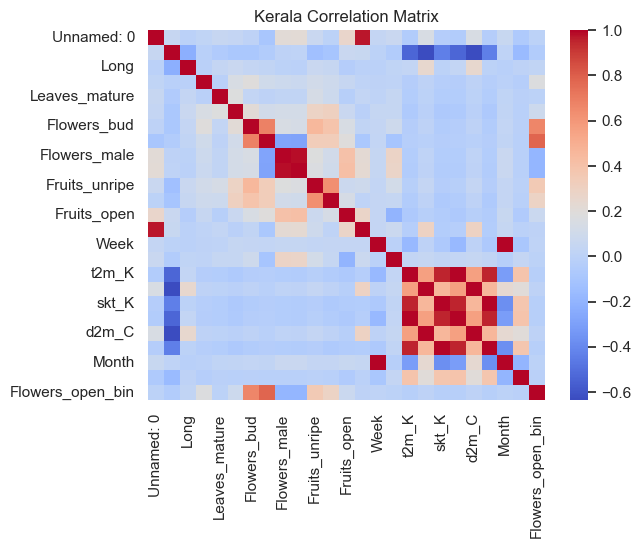

In [84]:
correlation_matrix_kerala = df_kerala.corr(numeric_only=True)
sns.heatmap(correlation_matrix_kerala, cmap='coolwarm', annot=False)
plt.title("Kerala Correlation Matrix")
plt.show()


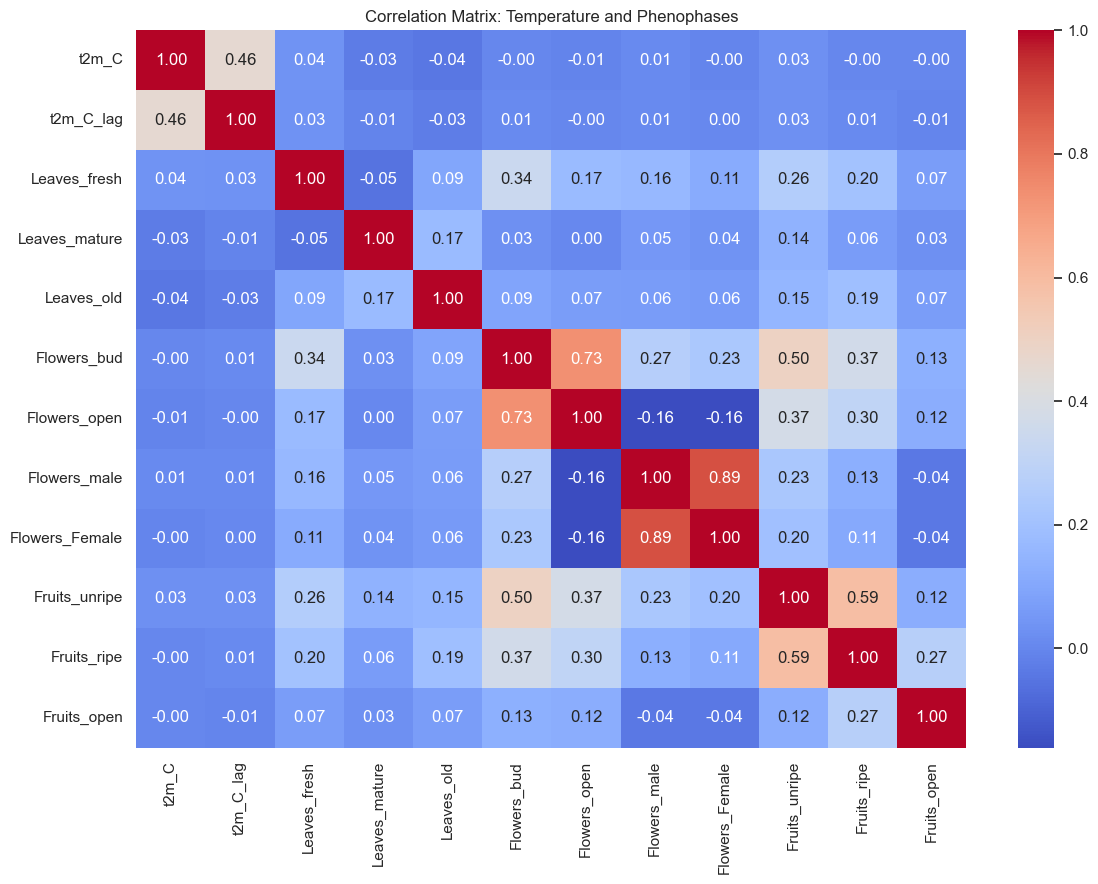

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_lagged = df_kerala.copy()
df_lagged['t2m_C_lag'] = df_lagged.groupby('Species_id')['t2m_C'].shift(1)

#Filter out invalid phenophase values (e.g., -2)
valid_corr_df = df_lagged.copy()
phenophase_cols = ['Leaves_fresh', 'Leaves_mature', 'Leaves_old',
                   'Flowers_bud', 'Flowers_open', 'Flowers_male', 'Flowers_Female',
                   'Fruits_unripe', 'Fruits_ripe', 'Fruits_open']

for col in phenophase_cols:
    valid_corr_df = valid_corr_df[valid_corr_df[col] >= 0]

cols_to_keep = ['t2m_C', 't2m_C_lag'] + phenophase_cols
df_corr = valid_corr_df[cols_to_keep].select_dtypes(include='number')

#correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Temperature and Phenophases")
plt.tight_layout()
plt.show()




c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


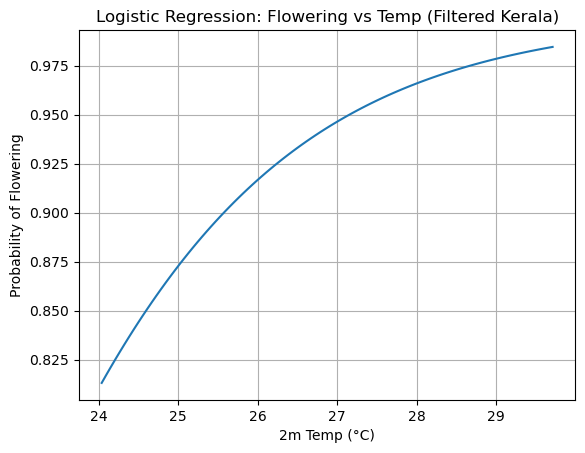

In [ ]:
kerala_df = df[df['State_name'] == 'Kerala'] 

#filter to top flowering species
top_species = kerala_df.groupby('Species_name')['Flowers_open'].mean().nlargest(10).index
kerala_top = kerala_df[kerala_df['Species_name'].isin(top_species)]

kerala_top = kerala_top.copy()
kerala_top['Flowering_bin'] = (kerala_top['Flowers_open'] > 0).astype(int)

X = kerala_top[['t2m_C']].dropna()
y = kerala_top.loc[X.index, 'Flowering_bin']

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

model = LogisticRegression()
model.fit(X, y)

temps = np.linspace(X['t2m_C'].min(), X['t2m_C'].max(), 100).reshape(-1, 1)
probs = model.predict_proba(temps)[:, 1]

# Plot
plt.plot(temps, probs)
plt.title("Logistic Regression: Flowering vs Temp (Filtered Kerala)")
plt.xlabel("2m Temp (°C)")
plt.ylabel("Probability of Flowering")
plt.grid(True)
plt.show()





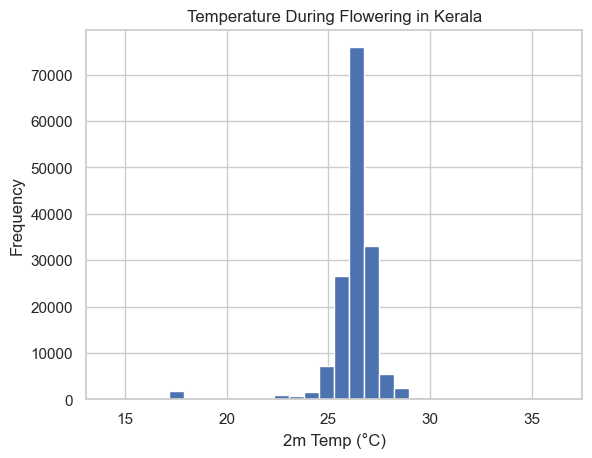

In [100]:
flowering_temps_kerala = df_kerala[df_kerala['Flowers_open'] > 0]['t2m_C']
flowering_temps_kerala.hist(bins=30)
plt.title("Temperature During Flowering in Kerala")
plt.xlabel("2m Temp (°C)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


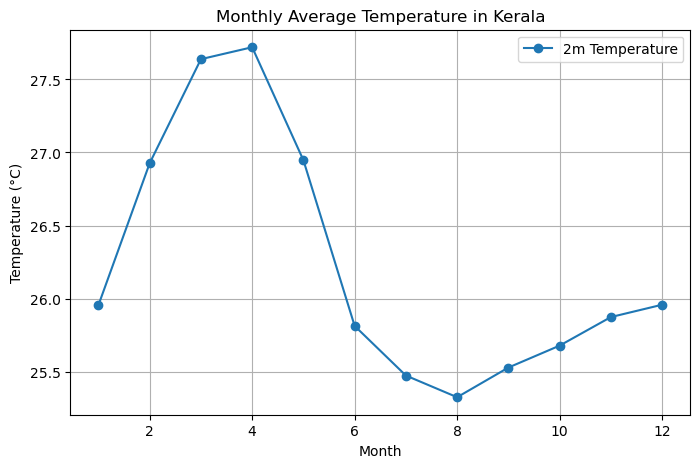

In [ ]:
# Group by month and calculate average temperature
monthly_avg_kerala = df_kerala.groupby('Month')[['t2m_C']].mean().reset_index()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
monthly_avg_kerala.plot(x='Month', y='t2m_C', ax=ax, marker='o')

ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Month")
ax.set_title("Monthly Average Temperature in Kerala")
ax.grid(True)
ax.legend(["2m Temperature"])

plt.show()



In [19]:
# Keep only valid phenophase values: usually 0 = no, 1 = yes; ignore -2 or NaN
valid_df = df_kerala.copy()
valid_df = valid_df[(valid_df['Flowers_open'] >= 0) & (valid_df['Fruits_ripe'] >= 0)]

species_summary_kerala = (
    valid_df.groupby('Species_name')[['t2m_C', 'Flowers_open', 'Fruits_ripe']]
    .mean()
    .round(2)
    .rename(columns={
        't2m_C': 'Avg Temp (°C)',
        'Flowers_open': 'Avg Flowers Open',
        'Fruits_ripe': 'Avg Fruits Ripe'
    })
    .sort_values('Avg Flowers Open', ascending=False)
)

species_summary_kerala.head(20)


,Avg Temp (°C),Avg Flowers Open,Avg Fruits Ripe
Species_name,,,
Broken Bones Tree-Oroxylum Indicum,26.82,2.00,2.00
Pyinma tree-Lagerstroemia hypoleuca,26.17,2.00,0.00
Meethabhaji-Champereia manillana,26.24,2.00,0.00
Caribbean Trumpet Tree-Tabebuia aurea,27.10,1.75,0.25
Croaya-Tabernaemontana crispa,26.86,1.69,0.47
East Indian satinwood-Chloroxylon swietenia,27.21,1.62,1.00
Walnut-Juglans regia,26.32,1.61,1.68
Sohiong-Prunus nepalensis,26.52,1.50,1.50
Badminton-ball Tree-Parkia biglandulosa,26.77,1.50,1.46


In [ ]:
valid_df = df_kerala.copy()

phenophase_cols = [
    'Flowers_open', 'Fruits_ripe', 'Leaves_fresh', 'Leaves_mature', 'Leaves_old',
    'Flowers_bud', 'Fruits_unripe', 'Fruits_open'
]

#Filter out negative values for any phenophase
for col in phenophase_cols:
    valid_df = valid_df[valid_df[col] >= 0]

# Group by species
species_phenology_summary = (
    valid_df.groupby('Species_name')[['t2m_C'] + phenophase_cols]
    .mean()
    .round(2)
    .rename(columns={'t2m_C': 'Avg Temp (°C)'})
    .sort_values('Flowers_open', ascending=False) 
)

species_phenology_summary.head(20)  # Top 20 species


,Avg Temp (°C),Flowers_open,Fruits_ripe,Leaves_fresh,Leaves_mature,Leaves_old,Flowers_bud,Fruits_unripe,Fruits_open
Species_name,,,,,,,,,
Caribbean Trumpet Tree-Tabebuia aurea,27.33,2.00,0.00,0.33,2.00,1.00,0.33,0.00,0.00
Croaya-Tabernaemontana crispa,26.87,1.70,0.46,1.38,1.77,0.51,1.71,1.48,0.01
East Indian satinwood-Chloroxylon swietenia,27.32,1.57,1.00,1.86,1.57,1.00,1.29,1.00,0.71
Badminton-ball Tree-Parkia biglandulosa,26.80,1.53,1.47,1.90,1.78,1.69,1.51,1.55,1.39
Kanak Champa-Pterospermum acerifolium,26.17,1.50,1.08,1.54,1.79,1.33,1.42,1.29,0.92
Ber-Ziziphus mauritiana,27.15,1.50,0.00,2.00,2.00,1.00,1.50,0.50,0.00
Floss Silk Tree-Ceiba speciosa,26.69,1.43,0.29,1.29,1.86,0.64,1.36,0.36,0.29
Oleander-Nerium oleander,26.55,1.43,0.48,1.52,1.72,0.81,1.37,0.48,0.00
Ghost Tree-Sterculia urens,26.85,1.41,0.32,1.35,1.97,0.76,1.38,0.71,0.26


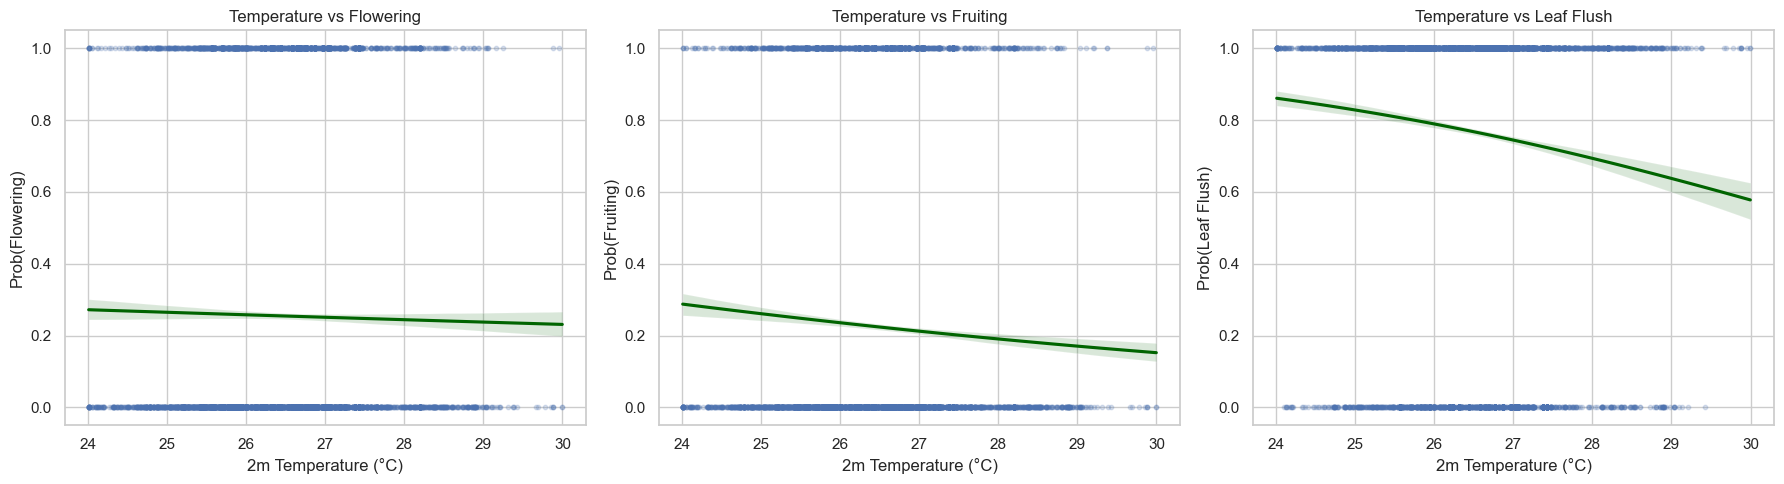

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

filtered = df_kerala[
    (df_kerala['t2m_C'].between(24, 30)) &  # Kerala-relevant temp range
    (df_kerala['Flowers_open'].isin([0, 1])) &
    (df_kerala['Fruits_ripe'].isin([0, 1])) &
    (df_kerala['Leaves_fresh'].isin([0, 1]))
].dropna(subset=['t2m_C', 'Flowers_open', 'Fruits_ripe', 'Leaves_fresh']) \
 .sample(n=10000, random_state=42)  

# Plotting logistic regression for each phenophase
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for ax, ycol, label in zip(
    axs,
    ['Flowers_open', 'Fruits_ripe', 'Leaves_fresh'],
    ['Flowering', 'Fruiting', 'Leaf Flush']
):
    sns.regplot(
        x='t2m_C',
        y=ycol,
        data=filtered,
        logistic=True,
        scatter_kws={'alpha': 0.2, 's': 10},
        line_kws={'color': 'darkgreen'},
        ax=ax
    )
    ax.set_title(f"Temperature vs {label}")
    ax.set_xlabel("2m Temperature (°C)")
    ax.set_ylabel(f"Prob({label})")

plt.tight_layout()
plt.show()


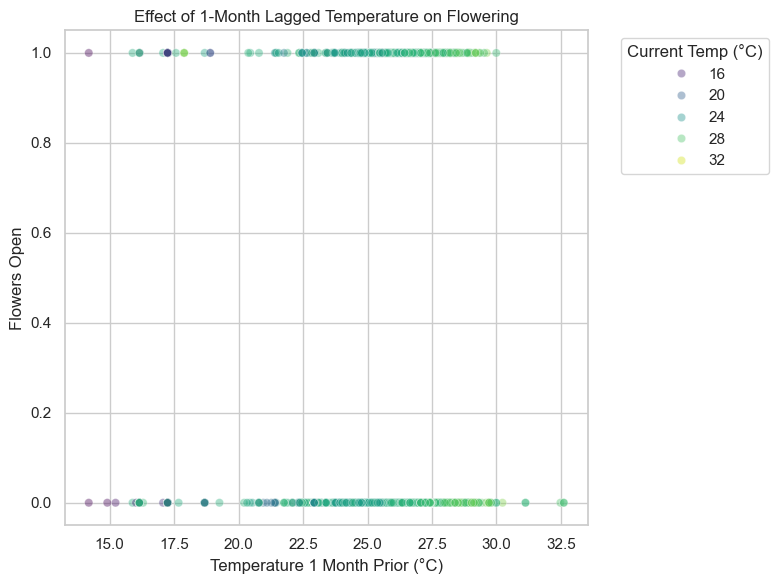

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_kerala = df[df['State_name'] == 'Kerala'].copy()
df_kerala['Week'] = pd.to_numeric(df_kerala['Week'], errors='coerce')
df_kerala = df_kerala.sort_values(['Species_name', 'Year', 'Week'])

# Lag temperature by 1 month within each species group
df_kerala['t2m_C_lag'] = df_kerala.groupby('Species_name')['t2m_C'].shift(1)

# Filter and drop rows with missing/invalid values
df_lagged = df_kerala[
    (df_kerala['t2m_C_lag'].notna()) &
    (df_kerala['Flowers_open'].isin([0, 1]))
]

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_lagged.sample(10000, random_state=1),
    x='t2m_C_lag',
    y='Flowers_open',
    hue='t2m_C',  # current temperature
    palette='viridis',
    alpha=0.4
)

plt.title("Effect of 1-Month Lagged Temperature on Flowering")
plt.xlabel("Temperature 1 Month Prior (°C)")
plt.ylabel("Flowers Open")
plt.legend(title="Current Temp (°C)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


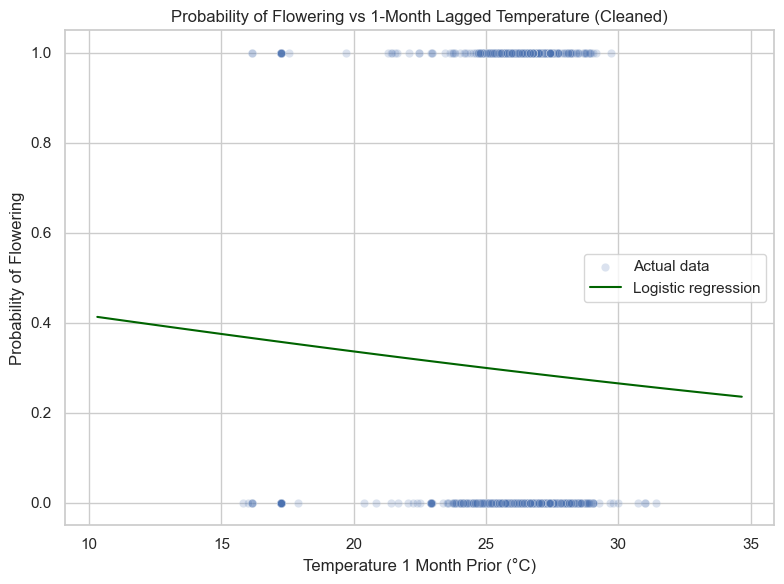

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import numpy as np

# Filter Kerala and drop NaNs
df_kerala = df[df['State_name'] == 'Kerala'].copy()
df_kerala['Week'] = pd.to_numeric(df_kerala['Week'], errors='coerce')
df_kerala = df_kerala.sort_values(['Species_name', 'Year', 'Week'])
df_kerala['t2m_C_lag'] = df_kerala.groupby('Species_name')['t2m_C'].shift(1)  #approx 1 month = 4 weeks

df_kerala = df_kerala[(df_kerala['t2m_C'] > 5) & (df_kerala['t2m_C_lag'] > 5)]

# Filter valid rows and realistic lagged temps
df_clean = df_kerala[
    (df_kerala['t2m_C_lag'].between(10, 35)) &
    (df_kerala['Flowers_open'].isin([0, 1]))
].dropna(subset=['t2m_C_lag', 'Flowers_open'])

X = df_clean[['t2m_C_lag']]
y = df_clean['Flowers_open']

model = LogisticRegression()
model.fit(X, y)
temp_range = np.linspace(X['t2m_C_lag'].min(), X['t2m_C_lag'].max(), 100).reshape(-1, 1)
probs = model.predict_proba(temp_range)[:, 1]

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='t2m_C_lag', y='Flowers_open', data=df_clean.sample(3000, random_state=1), alpha=0.2, label='Actual data')
plt.plot(temp_range, probs, color='darkgreen', label='Logistic regression')
plt.xlabel("Temperature 1 Month Prior (°C)")
plt.ylabel("Probability of Flowering")
plt.title("Probability of Flowering vs 1-Month Lagged Temperature (Cleaned)")
plt.legend()
plt.tight_layout()
plt.show()
